# 벡터데이터 베이스를 기준으로 불량상품 골라내기

정상이미지와 불량이미지를 벡터DB(chromaDB)에 저장하고 새로운 이미지가 들어오면 정상인지 불량인지 판단

In [13]:
!pip install -q chromadb torch pillow transformers matplotlib
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 28.3 MB/s eta 0:00:00


In [15]:
import os
import torch
import chromadb
import matplotlib.pyplot as plt
import koreanize_matplotlib

from PIL import Image
from collections import Counter
from transformers import CLIPProcessor, CLIPModel

In [16]:
# 이미지 파일 준비 확인
normal_images = ["normal_1.jpg", "normal_2.jpg", "normal_3.jpg"]  # 정상 이미지 목록
bad_images = ["bad_1.jpg", "bad_2.png", "bad_3.jpg"]  # 불량 이미지 목록
test_image = "test_2.jpeg"  # 판정할 테스트 이미지 파일명

all_images = normal_images + bad_images + [test_image]  # 전체 이미지 목록을 만든다.

for img_path in all_images:
    if os.path.exists(img_path):
        print("파일 확인:", img_path)
    else:
        print("파일 없음:", img_path)

파일 확인: normal_1.jpg
파일 확인: normal_2.jpg
파일 확인: normal_3.jpg
파일 확인: bad_1.jpg
파일 확인: bad_2.png
파일 확인: bad_3.jpg
파일 확인: test_2.jpeg


In [17]:
# CLIP 모델 준비
model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)  # CLIP 전처리 도구를 불러온다.
model = CLIPModel.from_pretrained(model_name)  # CLIP 모델을 불러온다.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()
print("사용 장치:", device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

사용 장치: cpu


In [18]:
# 이미지 파일을 CLIP 벡터로 변환하는 함수
def image_to_vector(img_path):
    image = Image.open(img_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        vision_outputs = model.vision_model(
            pixel_values=pixel_values  # 전처리된 이미지 텐서를 이미지 인코더에 넣는다.
        )

        pooled_output = vision_outputs.pooler_output

        image_features = model.visual_projection(
            pooled_output  # CLIP 공통 임베딩 공간으로 변환한다.
        )

    image_features = image_features / image_features.norm(
        p=2,
        dim=-1,
        keepdim=True
    )

    vec = image_features.squeeze(0).cpu().numpy()

    return vec.tolist()  # ChromaDB에 저장할 수 있도록 리스트로 반환한다.

client = chromadb.Client()

try:
    client.delete_collection("product_images")  # 기존 컬렉션이 있으면 삭제
except:
    pass

collection = client.create_collection(
    name="product_images",
    metadata={"hnsw:space": "cosine"}
)

print("ChromaDB 컬렉션 준비 완료")

ChromaDB 컬렉션 준비 완료


In [19]:
train_images = []  # VectorDB에 저장할 이미지 정보를 담을 리스트다.

for img_path in normal_images:
    train_images.append((img_path, "normal"))  # 정상 이미지에는 normal 라벨을 붙인다.

for img_path in bad_images:
    train_images.append((img_path, "bad"))     # 불량 이미지에는 bad 라벨을 붙인다.

# 정상/불량 이미지 벡터를 VectorDB에 저장
for i, (img_path, label) in enumerate(train_images):
    if not os.path.exists(img_path):  # 이미지 파일이 실제로 있는지 확인한다.
        print("파일 없음:", img_path)
        continue

    vec = image_to_vector(img_path)  # 이미지를 CLIP 벡터로 변환한다.

    collection.upsert(
        ids=[str(i)],             # 각 이미지의 고유 ID를 저장한다.
        embeddings=[vec],      # 이미지 벡터를 저장한다.
        documents=[img_path],  # 이미지 파일명을 문서 정보로 저장한다.
        metadatas=[{"filename": img_path, "label": label}]  # 파일명과 정상/불량 라벨을 저장한다.
    )
    print(f"저장 완료: {img_path} / 라벨: {label}")

print("VectorDB 저장 개수:", collection.count())

저장 완료: normal_1.jpg / 라벨: normal
저장 완료: normal_2.jpg / 라벨: normal
저장 완료: normal_3.jpg / 라벨: normal
저장 완료: bad_1.jpg / 라벨: bad


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


저장 완료: bad_2.png / 라벨: bad
저장 완료: bad_3.jpg / 라벨: bad
VectorDB 저장 개수: 6


In [20]:
# 테스트 이미지 판정 함수
def predict_image(test_img_path, top_k=3):
    if not os.path.exists(test_img_path):  # 테스트 이미지가 존재하는지 확인한다.
        print("테스트 이미지가 없습니다:", test_img_path)
        return

    if collection.count() == 0:  # VectorDB에 저장된 이미지가 있는지 확인한다.
        print("VectorDB에 저장된 이미지가 없습니다.")
        return

    test_vec = image_to_vector(test_img_path)  # 테스트 이미지를 CLIP 벡터로 변환한다.

    result = collection.query(
        query_embeddings=[test_vec],
        n_results=min(top_k, collection.count()),
        include=["documents", "metadatas", "distances"]
    )

    labels = []  # 검색된 이미지들의 라벨을 저장할 리스트다.
    print("\n테스트 이미지:", test_img_path)
    print("가까운 이미지 검색 결과:")

    for rank, (doc, meta, dist) in enumerate(
        zip(
            result["documents"][0],
            result["metadatas"][0],
            result["distances"][0]
        ), start=1
    ):
        labels.append(meta["label"])
        print(f"\n{rank}위")
        print("파일명:", meta["filename"])
        print("라벨:", meta["label"])
        print("거리:", round(dist, 4))

    vote = Counter(labels)  # 검색된 라벨들의 개수를 센다.
    final_label = vote.most_common(1)[0][0]  # 가장 많이 나온 라벨을 최종 판정으로 사용한다.
    print("\n라벨 투표 결과:", dict(vote))

    if final_label == "normal":
        print("최종 판정: 정상 제품으로 판단")
    else:
        print("최종 판정: 불량 제품으로 판단")

    # 테스트 이미지와 검색 결과 시각화
    count = len(result["documents"][0])  # 검색 결과 개수를 구한다.

    fig, axes = plt.subplots(1, count + 1, figsize=(4 * (count + 1), 4))  # 테스트이미지와 검색결과 나란히 표시
    axes[0].imshow(Image.open(test_img_path).convert("RGB"))  # 테스트 이미지를 표시한다.
    axes[0].set_title("Test Image")     # 테스트 이미지 제목을 표시한다.
    axes[0].axis("off")

    for i, (doc, meta, dist) in enumerate(
        zip(
            result["documents"][0],  # 검색된 이미지 파일명 목록이다.
            result["metadatas"][0],  # 검색된 이미지 메타데이터 목록이다.
            result["distances"][0]  # 거리 목록이다.
        )
    ):
        axes[i + 1].imshow(Image.open(doc).convert("RGB"))  # 검색된 이미지를 표시한다.
        axes[i + 1].set_title(f"{meta['label']}\n{meta['filename']}\n거리:{dist:.3f}")  # 라벨,파일명,거리 표시.
        axes[i + 1].axis("off")

    plt.show()


테스트 이미지: test_2.jpeg
가까운 이미지 검색 결과:

1위
파일명: normal_3.jpg
라벨: normal
거리: 0.2096

2위
파일명: normal_1.jpg
라벨: normal
거리: 0.2433

3위
파일명: bad_1.jpg
라벨: bad
거리: 0.2688

라벨 투표 결과: {'normal': 2, 'bad': 1}
최종 판정: 정상 제품으로 판단


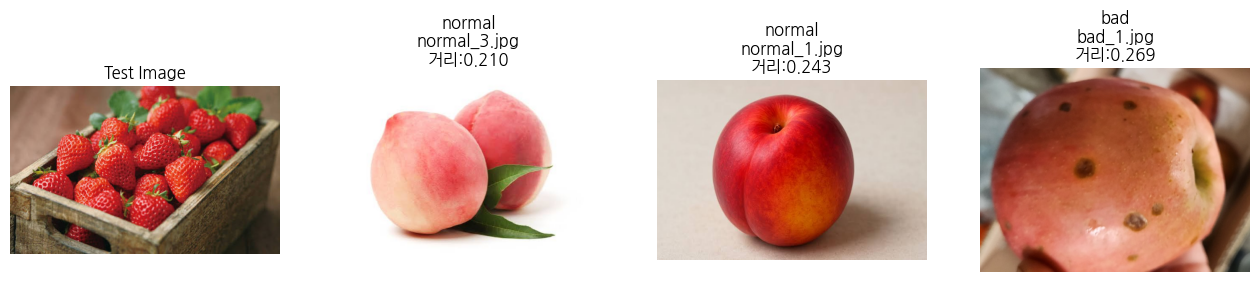

In [21]:
# 테스트 실행
predict_image(test_image, top_k=3)